# **Social Network Analysis with R**

Install Required R Package

In [1]:
if (!requireNamespace("igraph", quietly = TRUE)) {
    install.packages("igraph", repos = "https://cloud.r-project.org")
}

library(igraph)

cat("igraph package loaded successfully.\n")
cat("igraph version:", as.character(packageVersion("igraph")), "\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




igraph package loaded successfully.
igraph version: 2.3.3 


Simple Undirected Network

Warning message:
“`graph()` was deprecated in igraph 2.1.0.
ℹ Please use `make_graph()` instead.”


Number of nodes: 7 
Number of edges: 4 


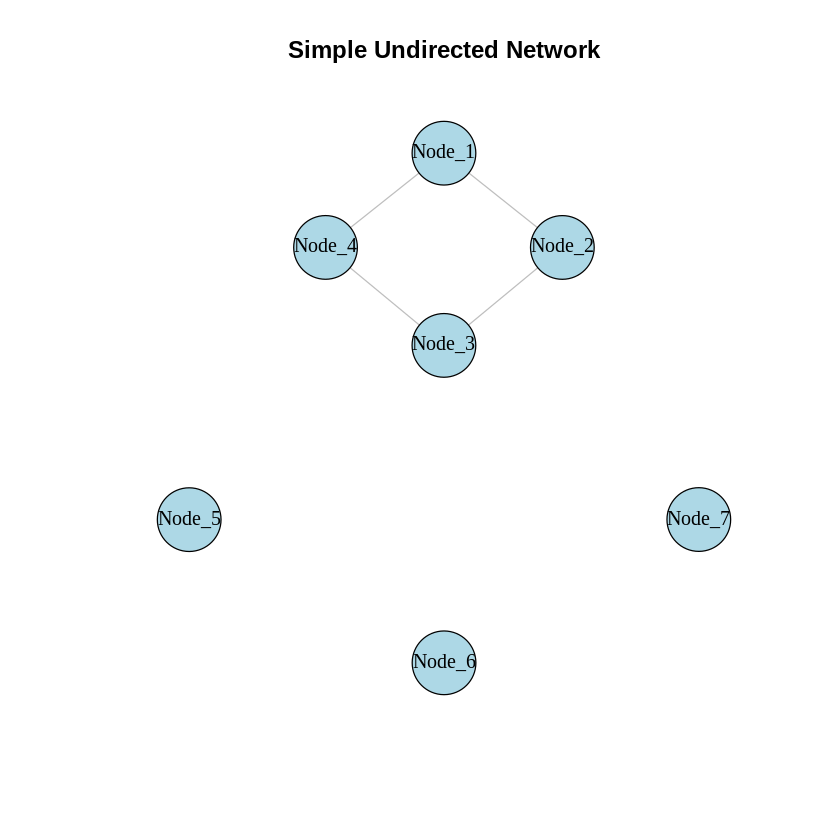

In [2]:
# Create a simple undirected network
g <- graph(
    c(1, 2,
      2, 3,
      3, 4,
      4, 1),
    directed = FALSE,
    n = 7
)

# Add labels
V(g)$name <- paste0("Node_", V(g))

# Display network information
cat("Number of nodes:", vcount(g), "\n")
cat("Number of edges:", ecount(g), "\n")

# Visualize
plot(
    g,
    vertex.color = "lightblue",
    vertex.size = 25,
    vertex.label.color = "black",
    edge.color = "gray",
    main = "Simple Undirected Network"
)

Small Directed Network

Number of nodes: 4 
Number of edges: 5 


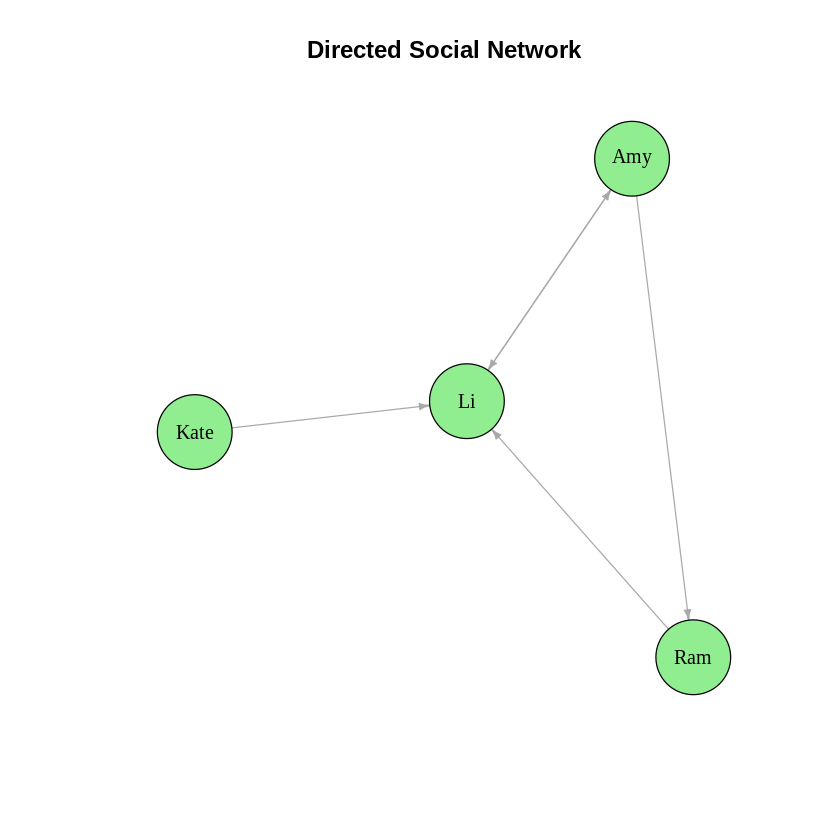

In [3]:
# Create a directed network with named nodes
g1 <- graph(
    c(
        "Amy", "Ram",
        "Ram", "Li",
        "Li", "Amy",
        "Amy", "Li",
        "Kate", "Li"
    ),
    directed = TRUE
)

# Display network information
cat("Number of nodes:", vcount(g1), "\n")
cat("Number of edges:", ecount(g1), "\n")

# Visualize
plot(
    g1,
    vertex.color = "lightgreen",
    vertex.size = 30,
    vertex.label.color = "black",
    edge.arrow.size = 0.4,
    main = "Directed Social Network"
)

Degree Centrality

In [4]:
cat("====================================\n")
cat("DEGREE CENTRALITY\n")
cat("====================================\n")

degree_all <- degree(g1, mode = "all")
degree_in  <- degree(g1, mode = "in")
degree_out <- degree(g1, mode = "out")

degree_table <- data.frame(
    Node = V(g1)$name,
    Total_Degree = degree_all,
    In_Degree = degree_in,
    Out_Degree = degree_out
)

print(degree_table)

DEGREE CENTRALITY
     Node Total_Degree In_Degree Out_Degree
Amy   Amy            3         1          2
Ram   Ram            2         1          1
Li     Li            4         3          1
Kate Kate            1         0          1


Diameter and Density

In [5]:
cat("====================================\n")
cat("NETWORK CHARACTERISTICS\n")
cat("====================================\n")

# Diameter
network_diameter <- diameter(
    g1,
    directed = FALSE,
    weights = NA
)

# Density
network_density <- edge_density(
    g1,
    loops = FALSE
)

# Reciprocity
network_reciprocity <- reciprocity(g1)

cat("Network Diameter :", network_diameter, "\n")
cat("Network Density  :", round(network_density, 4), "\n")
cat("Reciprocity      :", round(network_reciprocity, 4), "\n")

NETWORK CHARACTERISTICS
Network Diameter : 2 
Network Density  : 0.4167 
Reciprocity      : 0.4 


Closeness Centrality

In [6]:
cat("====================================\n")
cat("CLOSENESS CENTRALITY\n")
cat("====================================\n")

closeness_values <- closeness(
    g1,
    mode = "all",
    weights = NA,
    normalized = TRUE
)

closeness_table <- data.frame(
    Node = V(g1)$name,
    Closeness = closeness_values
)

closeness_table <- closeness_table[
    order(-closeness_table$Closeness),
]

print(closeness_table)

CLOSENESS CENTRALITY
     Node Closeness
Li     Li      1.00
Amy   Amy      0.75
Ram   Ram      0.75
Kate Kate      0.60


Betweenness Centrality

In [7]:
cat("====================================\n")
cat("BETWEENNESS CENTRALITY\n")
cat("====================================\n")

betweenness_values <- betweenness(
    g1,
    directed = TRUE,
    weights = NA,
    normalized = TRUE
)

betweenness_table <- data.frame(
    Node = V(g1)$name,
    Betweenness = betweenness_values
)

betweenness_table <- betweenness_table[
    order(-betweenness_table$Betweenness),
]

print(betweenness_table)

BETWEENNESS CENTRALITY
     Node Betweenness
Li     Li   0.5000000
Amy   Amy   0.3333333
Ram   Ram   0.0000000
Kate Kate   0.0000000


Edge Betweenness

In [8]:
cat("====================================\n")
cat("EDGE BETWEENNESS\n")
cat("====================================\n")

edge_betweenness_values <- edge_betweenness(
    g1,
    directed = TRUE,
    weights = NA
)

edge_table <- data.frame(
    Edge = as_ids(E(g1)),
    Edge_Betweenness = edge_betweenness_values
)

print(edge_table)

EDGE BETWEENNESS
     Edge Edge_Betweenness
1 Amy|Ram                3
2  Ram|Li                2
3  Li|Amy                5
4  Amy|Li                1
5 Kate|Li                3


Load the Actual Dataset

In [9]:
cat("====================================\n")
cat("LOADING NETWORK DATASET\n")
cat("====================================\n")

data_url <- "https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv"

network_data <- read.csv(
    data_url,
    header = TRUE,
    stringsAsFactors = FALSE
)

cat("Dataset loaded successfully.\n\n")

cat("Number of rows:", nrow(network_data), "\n")
cat("Number of columns:", ncol(network_data), "\n\n")

cat("Column names:\n")
print(names(network_data))

cat("\nFirst few records:\n")
print(head(network_data))

LOADING NETWORK DATASET
Dataset loaded successfully.

Number of rows: 290 
Number of columns: 4 

Column names:
[1] "first"  "second" "grade"  "spec"  

First few records:
  first second grade spec
1    AA     DD     6    Y
2    AB     DD     6    R
3    AF     BA     6    Q
4    DD     DA     6    Q
5    CD     EC     6    X
6    DD     CE     6    Y


Check and Clean Dataset

In [10]:
cat("====================================\n")
cat("DATASET CHECK\n")
cat("====================================\n")

# Check missing values
cat("Missing values:\n")
print(colSums(is.na(network_data)))

# Remove rows containing missing values
network_data <- na.omit(network_data)

# Keep the two relationship columns
edges <- data.frame(
    from = as.character(network_data$first),
    to   = as.character(network_data$second),
    stringsAsFactors = FALSE
)

# Remove duplicate edges
edges <- unique(edges)

# Remove self-loops
edges <- edges[edges$from != edges$to, ]

cat("\nCleaned dataset:\n")
cat("Number of edges:", nrow(edges), "\n")

print(head(edges))

DATASET CHECK
Missing values:
 first second  grade   spec 
     0      0      0      0 

Cleaned dataset:
Number of edges: 147 
  from to
1   AA DD
2   AB DD
3   AF BA
4   DD DA
5   CD EC
6   DD CE


Create the Main Social Network

In [11]:
cat("====================================\n")
cat("CREATING SOCIAL NETWORK\n")
cat("====================================\n")

net <- graph_from_data_frame(
    edges,
    directed = TRUE
)

cat("Number of nodes:", vcount(net), "\n")
cat("Number of edges:", ecount(net), "\n")

# Assign node labels
V(net)$label <- V(net)$name

# Calculate degree
V(net)$degree <- degree(
    net,
    mode = "all"
)

cat("\nNetwork successfully created.\n")

CREATING SOCIAL NETWORK
Number of nodes: 52 
Number of edges: 147 

Network successfully created.


Display Network Summary

In [12]:
cat("====================================\n")
cat("NETWORK SUMMARY\n")
cat("====================================\n")

print(net)

cat("\nNetwork characteristics:\n")
cat("Nodes :", vcount(net), "\n")
cat("Edges :", ecount(net), "\n")
cat("Density :", round(edge_density(net), 4), "\n")

NETWORK SUMMARY
IGRAPH f938df6 DN-- 52 147 -- 
+ attr: name (v/c), label (v/c), degree (v/n)
+ edges from f938df6 (vertex names):
 [1] AA->DD AB->DD AF->BA DD->DA CD->EC DD->CE CD->FA CD->CC BA->AF CB->CA
[11] CC->CA CD->CA BC->CA ED->AD AE->AC AB->BA CA->CC EB->CC BF->CE BB->CD
[21] AC->AE CC->FB DC->BB BD->CF DB->DA DB->DD BC->AF CF->DE DF->BF BE->CA
[31] EA->CA BF->CA CE->CA AC->AD BD->BE AE->DF CB->DF AC->DF CD->DD EE->DD
[41] DB->AA AA->FC BE->CC EF->FD CF->FE BB->DD BA->AB BE->EE CE->CC ED->CC
[51] BB->CC BE->CE AC->CD ED->CD FF->CD DD->CD AE->GA BA->ED BE->ED EB->ED
[61] CD->ED FD->EF CD->BB BF->BB BC->BB BB->CF BE->CD BC->CD ED->AF BF->AF
[71] CF->AF GB->BC AF->BC AC->BA CF->AE DF->AA GC->AA ED->BF AF->BF AC->CA
+ ... omitted several edges

Network characteristics:
Nodes : 52 
Edges : 147 
Density : 0.0554 


Degree Distribution

Minimum degree : 1 
Maximum degree : 20 
Average degree : 5.65 


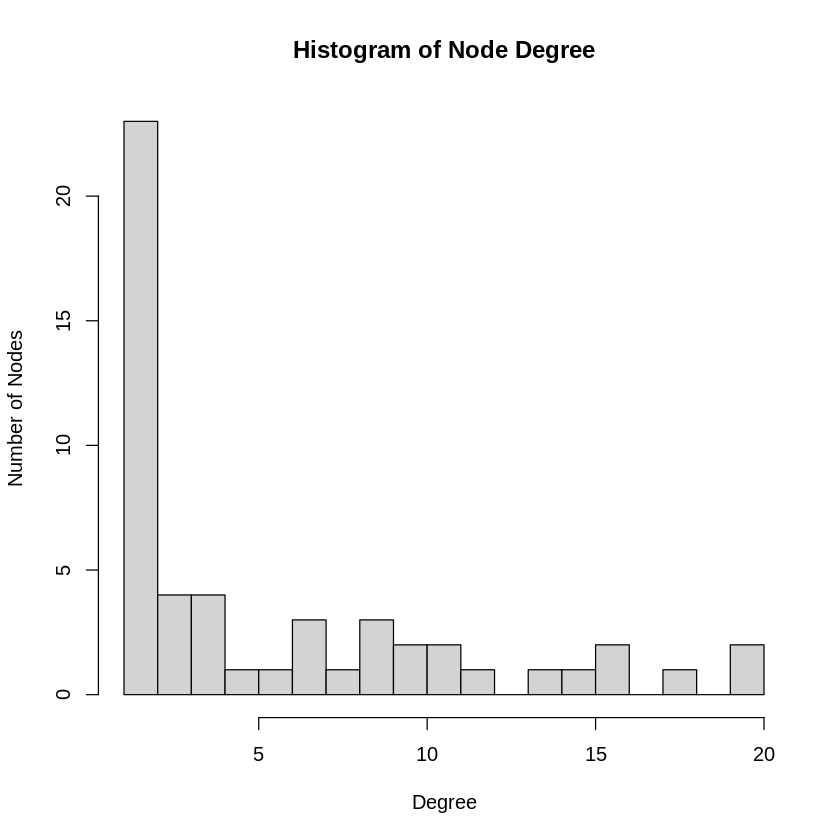

In [13]:
degree_values <- degree(
    net,
    mode = "all"
)

cat("Minimum degree :", min(degree_values), "\n")
cat("Maximum degree :", max(degree_values), "\n")
cat("Average degree :", round(mean(degree_values), 2), "\n")

hist(
    degree_values,
    main = "Histogram of Node Degree",
    xlab = "Degree",
    ylab = "Number of Nodes",
    breaks = max(1, min(15, length(unique(degree_values))))
)

Main Network Visualization

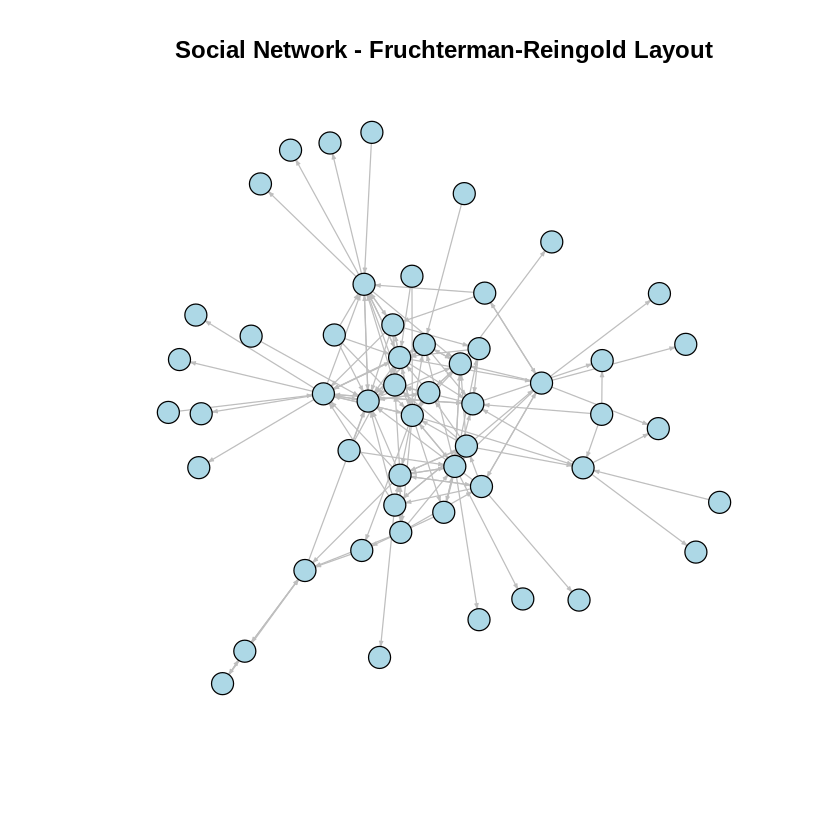

In [14]:
set.seed(123)

plot(
    net,
    layout = layout_with_fr(net),
    vertex.color = "lightblue",
    vertex.size = 8,
    vertex.label = NA,
    edge.arrow.size = 0.2,
    edge.color = "gray",
    main = "Social Network - Fruchterman-Reingold Layout"
)

Network Sized by Degree

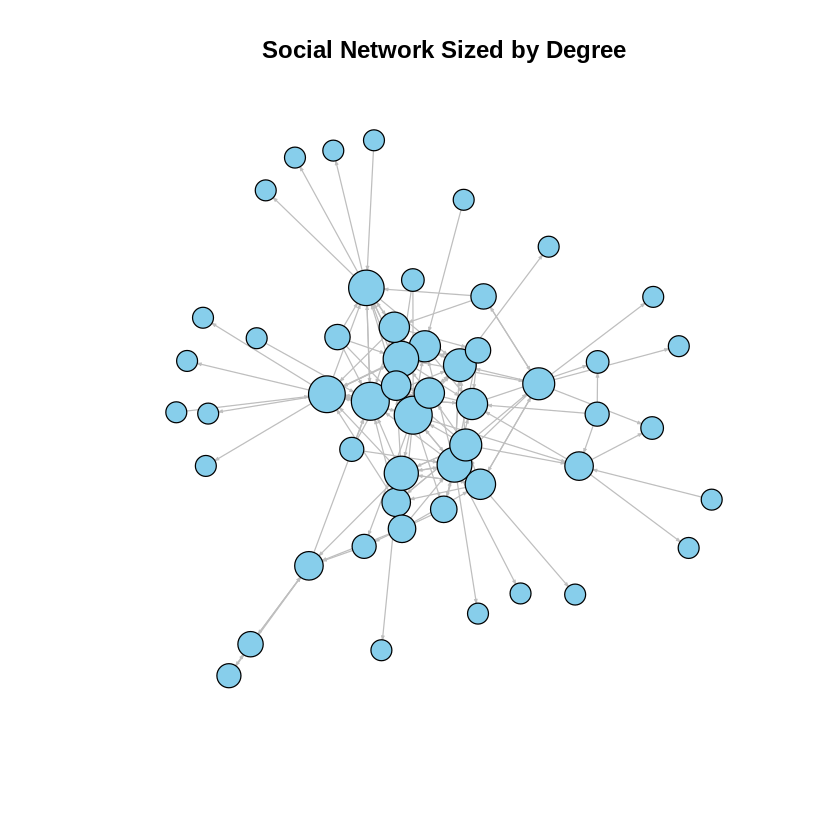

In [15]:
set.seed(123)

# Scale node size based on degree
node_size <- 5 + 2 * sqrt(V(net)$degree + 1)

plot(
    net,
    layout = layout_with_fr(net),
    vertex.size = node_size,
    vertex.color = "skyblue",
    vertex.label = NA,
    edge.arrow.size = 0.15,
    edge.color = "gray",
    main = "Social Network Sized by Degree"
)

Degree Centrality of Actual Network

In [16]:
degree_all <- degree(net, mode = "all")
degree_in  <- degree(net, mode = "in")
degree_out <- degree(net, mode = "out")

degree_results <- data.frame(
    Node = V(net)$name,
    Total_Degree = degree_all,
    In_Degree = degree_in,
    Out_Degree = degree_out
)

degree_results <- degree_results[
    order(-degree_results$Total_Degree),
]

cat("Top 10 nodes according to degree:\n\n")

print(
    head(degree_results, 10),
    row.names = FALSE
)

Top 10 nodes according to degree:

 Node Total_Degree In_Degree Out_Degree
   ED           20         8         12
   CA           20        14          6
   CD           18         9          9
   CC           16         9          7
   BB           16         9          7
   BA           15         7          8
   AC           14         6          8
   AF           12         8          4
   CF           11         4          7
   DF           11         3          8


Closeness Centrality of Actual Network

In [17]:
closeness_values <- closeness(
    net,
    mode = "all",
    weights = NA,
    normalized = TRUE
)

closeness_results <- data.frame(
    Node = V(net)$name,
    Closeness = closeness_values
)

closeness_results <- closeness_results[
    order(-closeness_results$Closeness),
]

cat("Top 10 nodes according to closeness:\n\n")

print(
    head(closeness_results, 10),
    row.names = FALSE
)

Top 10 nodes according to closeness:

 Node Closeness
   ED 0.5425532
   BB 0.5204082
   CD 0.5151515
   CA 0.5100000
   CC 0.4951456
   AF 0.4811321
   AC 0.4811321
   BC 0.4722222
   BA 0.4678899
   BE 0.4678899


Betweenness Centrality of Actual Network

In [18]:
betweenness_values <- betweenness(
    net,
    directed = TRUE,
    weights = NA,
    normalized = TRUE
)

betweenness_results <- data.frame(
    Node = V(net)$name,
    Betweenness = betweenness_values
)

betweenness_results <- betweenness_results[
    order(-betweenness_results$Betweenness),
]

cat("Top 10 nodes according to betweenness:\n\n")

print(
    head(betweenness_results, 10),
    row.names = FALSE
)

Top 10 nodes according to betweenness:

 Node Betweenness
   CD  0.14540697
   ED  0.13965954
   CA  0.11030256
   BB  0.10498947
   CC  0.08049168
   CF  0.07627468
   EA  0.07232697
   BA  0.06933261
   DD  0.06409617
   AC  0.06062019


HITS: Hub Scores

In [19]:
cat("====================================\n")
cat("HITS HUB SCORES\n")
cat("====================================\n")

hub_values <- hub_score(net)$vector

hub_results <- data.frame(
    Node = V(net)$name,
    Hub_Score = hub_values
)

hub_results <- hub_results[
    order(-hub_results$Hub_Score),
]

print(
    head(hub_results, 10),
    row.names = FALSE
)

HITS HUB SCORES


Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”


 Node Hub_Score
   ED 1.0000000
   BB 0.7754015
   CD 0.7551545
   BE 0.7329802
   BF 0.6895684
   BC 0.6788631
   AC 0.6486817
   DF 0.6382036
   CA 0.6324782
   EB 0.6011354


HITS: Authority Scores

In [20]:
cat("====================================\n")
cat("HITS AUTHORITY SCORES\n")
cat("====================================\n")

authority_values <- authority_score(net)$vector

authority_results <- data.frame(
    Node = V(net)$name,
    Authority_Score = authority_values
)

authority_results <- authority_results[
    order(-authority_results$Authority_Score),
]

print(
    head(authority_results, 10),
    row.names = FALSE
)

HITS AUTHORITY SCORES


Warning message:
“`authority_score()` was deprecated in igraph 2.1.0.
ℹ Please use `hits_scores()` instead.”


 Node Authority_Score
   CA       1.0000000
   CD       0.7137989
   CC       0.6964134
   BB       0.6911085
   ED       0.6656464
   AF       0.6652523
   CE       0.4803127
   AC       0.4367414
   BA       0.3940230
   DD       0.3777879


Visualize Hub Scores

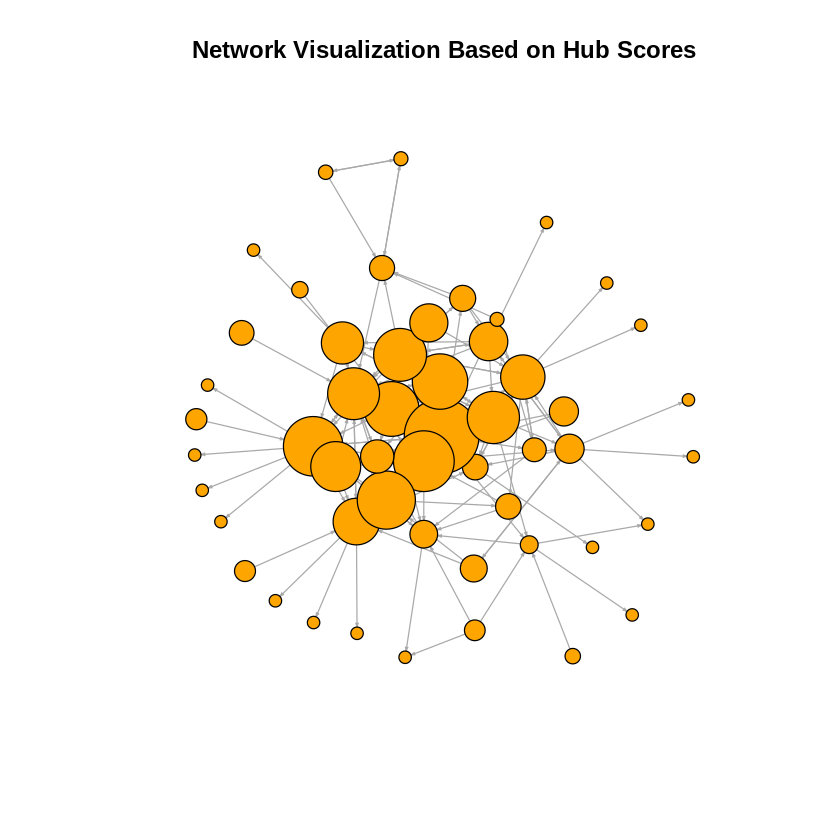

In [21]:
hub_size <- 5 + 25 * hub_values

set.seed(123)

plot(
    net,
    layout = layout_with_kk(net),
    vertex.size = hub_size,
    vertex.color = "orange",
    vertex.label = NA,
    edge.arrow.size = 0.15,
    main = "Network Visualization Based on Hub Scores"
)

Visualize Authority Scores

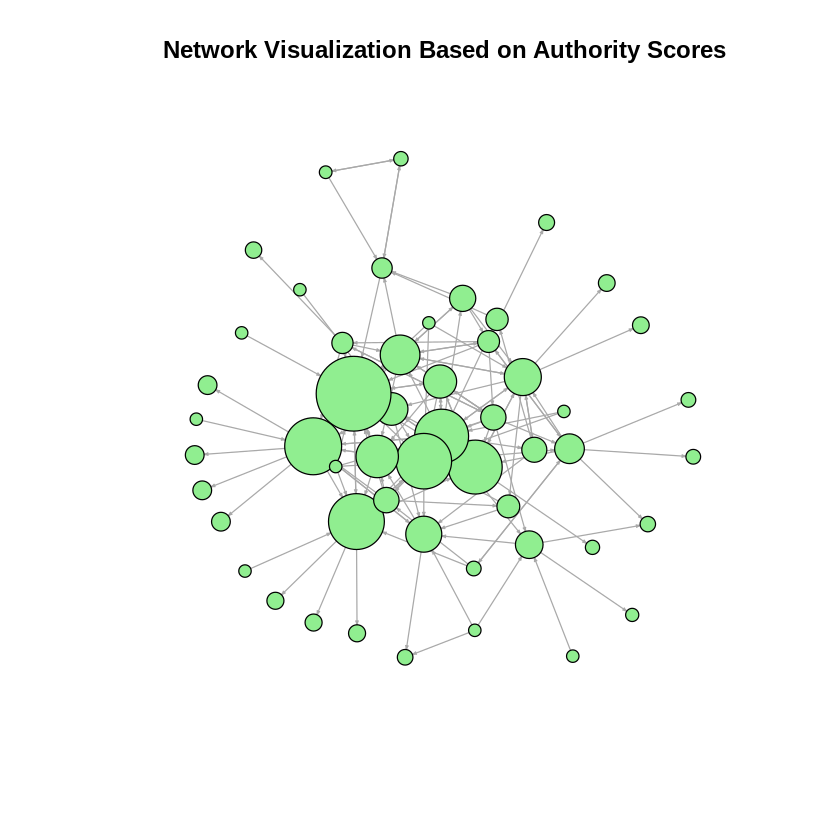

In [22]:
authority_size <- 5 + 25 * authority_values

set.seed(123)

plot(
    net,
    layout = layout_with_kk(net),
    vertex.size = authority_size,
    vertex.color = "lightgreen",
    vertex.label = NA,
    edge.arrow.size = 0.15,
    main = "Network Visualization Based on Authority Scores"
)

Identify Most Influential Nodes

In [23]:
cat("====================================\n")
cat("MOST INFLUENTIAL NODES\n")
cat("====================================\n")

top_n <- min(10, vcount(net))

cat("\nTop nodes by Degree:\n")
print(head(degree_results, top_n), row.names = FALSE)

cat("\nTop nodes by Closeness:\n")
print(head(closeness_results, top_n), row.names = FALSE)

cat("\nTop nodes by Betweenness:\n")
print(head(betweenness_results, top_n), row.names = FALSE)

cat("\nTop Hubs:\n")
print(head(hub_results, top_n), row.names = FALSE)

cat("\nTop Authorities:\n")
print(head(authority_results, top_n), row.names = FALSE)

MOST INFLUENTIAL NODES

Top nodes by Degree:
 Node Total_Degree In_Degree Out_Degree
   ED           20         8         12
   CA           20        14          6
   CD           18         9          9
   CC           16         9          7
   BB           16         9          7
   BA           15         7          8
   AC           14         6          8
   AF           12         8          4
   CF           11         4          7
   DF           11         3          8

Top nodes by Closeness:
 Node Closeness
   ED 0.5425532
   BB 0.5204082
   CD 0.5151515
   CA 0.5100000
   CC 0.4951456
   AF 0.4811321
   AC 0.4811321
   BC 0.4722222
   BA 0.4678899
   BE 0.4678899

Top nodes by Betweenness:
 Node Betweenness
   CD  0.14540697
   ED  0.13965954
   CA  0.11030256
   BB  0.10498947
   CC  0.08049168
   CF  0.07627468
   EA  0.07232697
   BA  0.06933261
   DD  0.06409617
   AC  0.06062019

Top Hubs:
 Node Hub_Score
   ED 1.0000000
   BB 0.7754015
   CD 0.7551545
   BE 0.732980

Community Detection

In [24]:
cat("====================================\n")
cat("COMMUNITY DETECTION\n")
cat("====================================\n")

# Convert directed network to undirected network
net_undirected <- as.undirected(
    net,
    mode = "collapse"
)

# Detect communities using Louvain algorithm
communities <- cluster_louvain(
    net_undirected
)

cat("Number of communities detected:",
    length(communities),
    "\n")

cat("\nCommunity membership:\n")
print(membership(communities))

COMMUNITY DETECTION


Warning message:
“`as.undirected()` was deprecated in igraph 2.1.0.
ℹ Please use `as_undirected()` instead.”


Number of communities detected: 6 

Community membership:
AA AB AF DD CD BA CB CC BC ED AE CA EB BF BB AC DC BD DB CF DF BE EA CE EE EF 
 1  2  3  1  4  3  5  6  3  2  5  5  6  5  6  5  2  6  1  6  5  6  2  5  6  2 
FF FD GB GC GD AD KA KF LC DA EC FA FB DE FC FE GA GE KB KC KD KE LB LA LD LE 
 4  2  3  1  6  2  3  2  5  1  4  4  6  6  1  1  5  6  6  6  4  5  4  3  3  3 


Community Sizes

In [25]:
cat("====================================\n")
cat("COMMUNITY SIZES\n")
cat("====================================\n")

community_sizes <- sizes(communities)

print(community_sizes)

cat("\nCommunity modularity:",
    round(modularity(communities), 4),
    "\n")

COMMUNITY SIZES
Community sizes
 1  2  3  4  5  6 
 7  8  8  6 10 13 

Community modularity: 0.3511 


Community Visualization

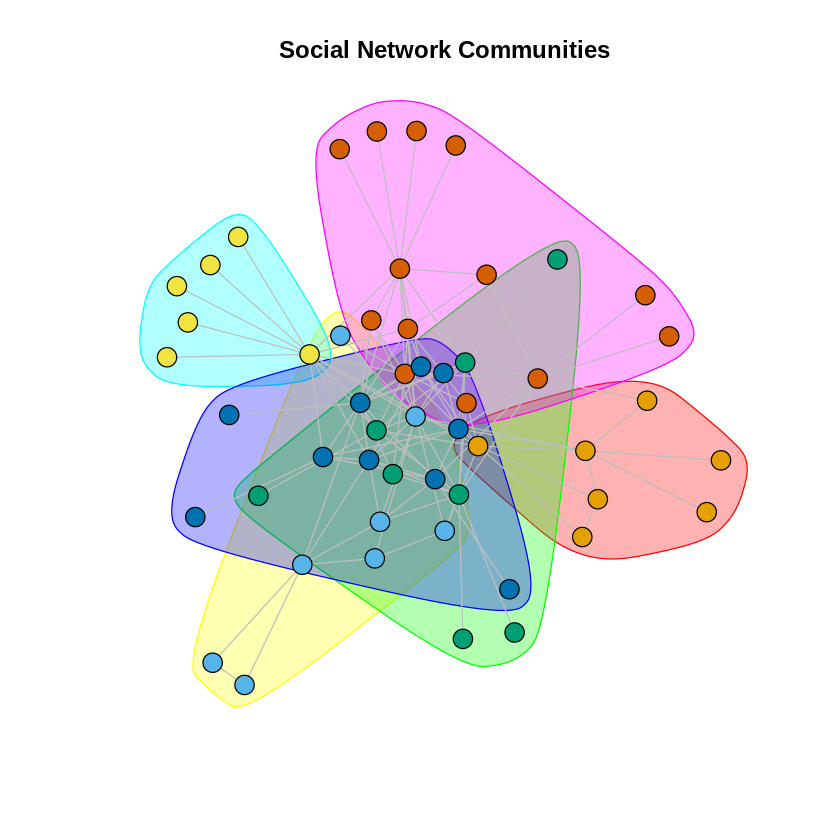

In [26]:
set.seed(123)

plot(
    communities,
    net_undirected,
    layout = layout_with_fr(net_undirected),
    vertex.size = 7,
    vertex.label = NA,
    edge.color = "gray",
    main = "Social Network Communities"
)

Highlight Top Degree Nodes

Top 5 highly connected nodes:
[1] "ED" "CA" "CD" "CC" "BB"


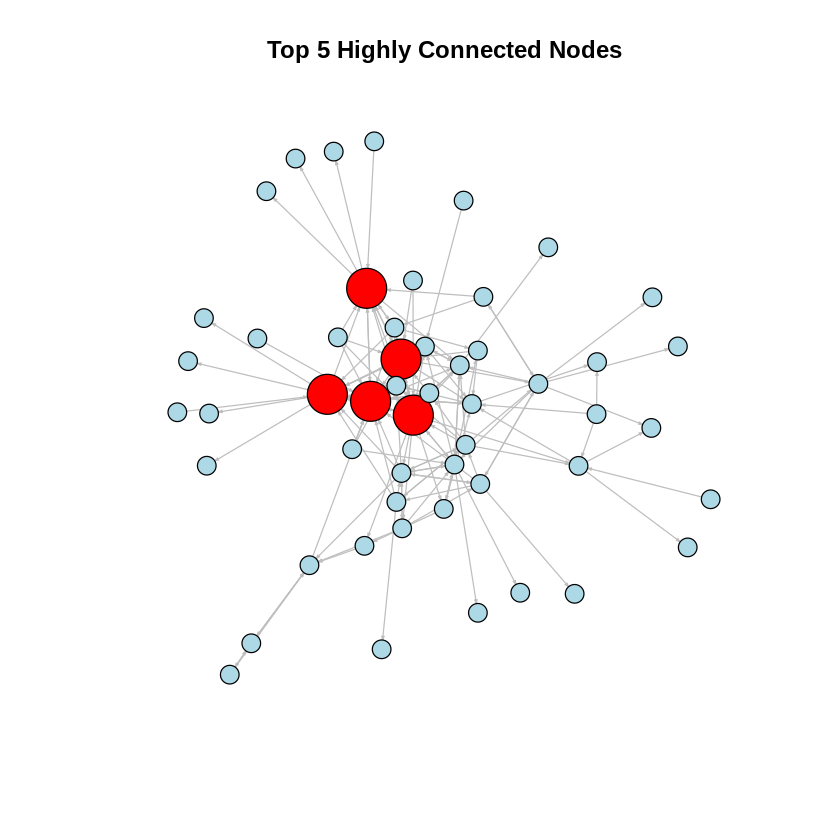

In [27]:
# Select top 5 nodes based on degree
top_degree_nodes <- order(
    degree(net, mode = "all"),
    decreasing = TRUE
)[1:min(5, vcount(net))]

# Default node properties
V(net)$color <- "lightblue"
V(net)$size <- 7

# Highlight top nodes
V(net)$color[top_degree_nodes] <- "red"
V(net)$size[top_degree_nodes] <- 15

set.seed(123)

plot(
    net,
    layout = layout_with_fr(net),
    vertex.label = NA,
    edge.arrow.size = 0.15,
    edge.color = "gray",
    main = "Top 5 Highly Connected Nodes"
)

cat("Top 5 highly connected nodes:\n")
print(V(net)$name[top_degree_nodes])

Combined Network Measures Table

In [28]:
combined_results <- data.frame(
    Node = V(net)$name,
    Degree = degree_all,
    Closeness = closeness_values,
    Betweenness = betweenness_values,
    Hub = hub_values,
    Authority = authority_values
)

combined_results <- combined_results[
    order(-combined_results$Degree),
]

cat("====================================\n")
cat("COMBINED NETWORK MEASURES\n")
cat("====================================\n\n")

print(
    head(combined_results, 15),
    row.names = FALSE
)

COMBINED NETWORK MEASURES

 Node Degree Closeness Betweenness       Hub Authority
   ED     20 0.5425532  0.13965954 1.0000000 0.6656464
   CA     20 0.5100000  0.11030256 0.6324782 1.0000000
   CD     18 0.5151515  0.14540697 0.7551545 0.7137989
   CC     16 0.4951456  0.08049168 0.5483421 0.6964134
   BB     16 0.5204082  0.10498947 0.7754015 0.6911085
   BA     15 0.4678899  0.06933261 0.5114629 0.3940230
   AC     14 0.4811321  0.06062019 0.6486817 0.4367414
   AF     12 0.4811321  0.03906676 0.2124537 0.6652523
   CF     11 0.4434783  0.07627468 0.2691747 0.2762266
   DF     11 0.4594595  0.01600747 0.6382036 0.2064867
   DD     10 0.4473684  0.06409617 0.2450555 0.3777879
   BC     10 0.4722222  0.03205573 0.6788631 0.3240770
   AE      9 0.4250000  0.04224264 0.4167186 0.1521709
   BF      9 0.4250000  0.02137535 0.6895684 0.3325041
   BE      9 0.4678899  0.01900607 0.7329802 0.2083931
